In [1]:
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
import numpy as np

In [4]:
import healpy as hp

In [5]:
NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 32 is 1.8 deg


In [6]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

12288


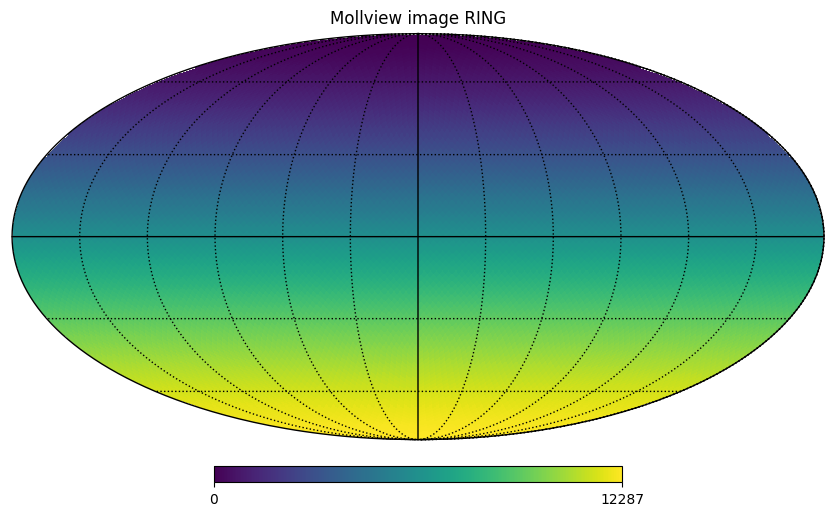

In [7]:
m = np.arange(NPIX)
hp.mollview(m, title="Mollview image RING")
hp.graticule()

In [8]:
vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
print(vec)

[-7.07106781e-01  7.07106781e-01  6.12323400e-17]


In [9]:
ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))

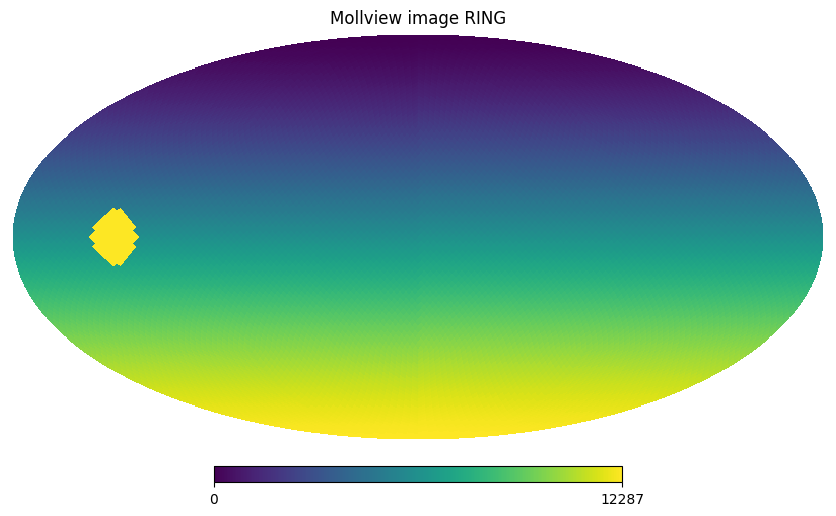

In [10]:
m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(m, title="Mollview image RING")

In [11]:
theta, phi = np.degrees(hp.pix2ang(nside=32, ipix=[0, 1, 2, 3, 4]))

In [12]:
theta

array([1.46197116, 1.46197116, 1.46197116, 1.46197116, 2.92418036])

In [13]:
phi

array([ 45. , 135. , 225. , 315. ,  22.5])

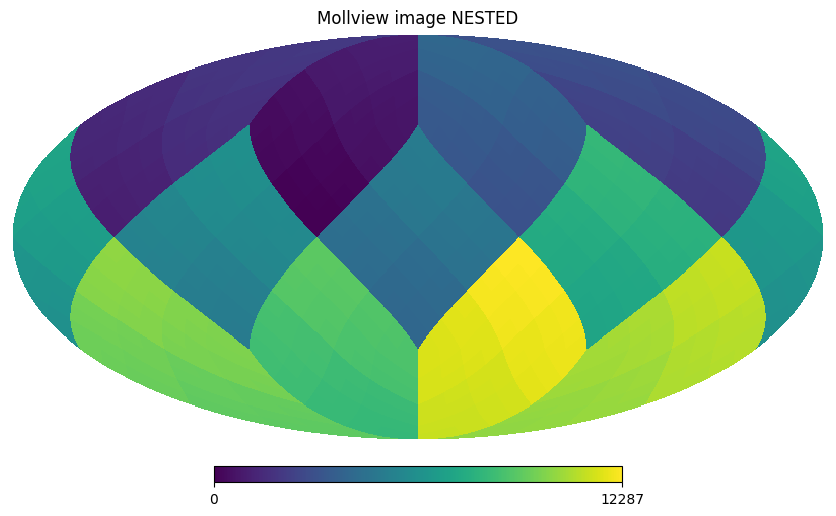

In [14]:
m = np.arange(NPIX)
hp.mollview(m, nest=True, title="Mollview image NESTED")

In [15]:
!wget -c http://lambda.gsfc.nasa.gov/data/map/dr4/skymaps/7yr/raw/wmap_band_iqumap_r9_7yr_W_v4.fits;wget -c http://lambda.gsfc.nas.gov/data/map/dr4/ancillary/mask/wmap_temperature_analysis_mask_r9_7yr_v4.fits

URL transformed to HTTPS due to an HSTS policy
--2026-01-22 15:57:59--  https://lambda.gsfc.nasa.gov/data/map/dr4/skymaps/7yr/raw/wmap_band_iqumap_r9_7yr_W_v4.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-01-22 15:58:00--  http://lambda.gsfc.nas.gov/data/map/dr4/ancillary/mask/wmap_temperature_analysis_mask_r9_7yr_v4.fits
Resolving lambda.gsfc.nas.gov (lambda.gsfc.nas.gov)... failed: nodename nor servname provided, or not known.
wget: unable to resolve host address ‘lambda.gsfc.nas.gov’


In [16]:
wmap_map_I = hp.read_map("wmap_band_iqumap_r9_7yr_W_v4.fits")

In [17]:
hp.write_map("my_map.fits", wmap_map_I, overwrite=True)

setting the output map dtype to [dtype('>f4')]


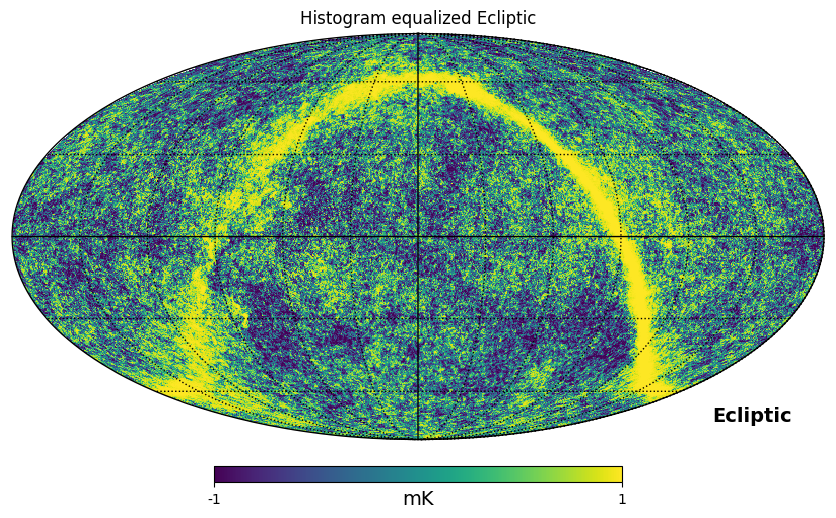

In [18]:
hp.mollview(
    wmap_map_I,
    coord=["G", "E"],
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist",
    min=-1,
    max=1,
)
hp.graticule()

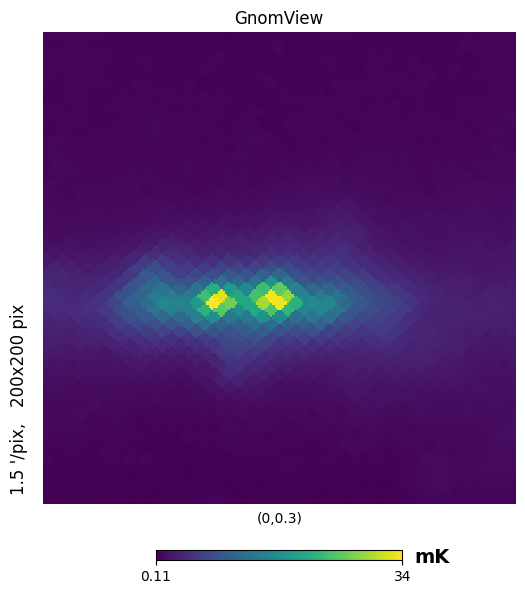

In [19]:
hp.gnomview(wmap_map_I, rot=[0, 0.3], title="GnomView", unit="mK", format="%.2g")

In [20]:
!wget -c https://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits

--2026-01-22 15:58:01--  https://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [21]:
mask = hp.read_map("wmap_temperature_analysis_mask_r9_7yr_v4.fits").astype(np.bool_)
wmap_map_I_masked = hp.ma(wmap_map_I)
wmap_map_I_masked.mask = np.logical_not(mask)

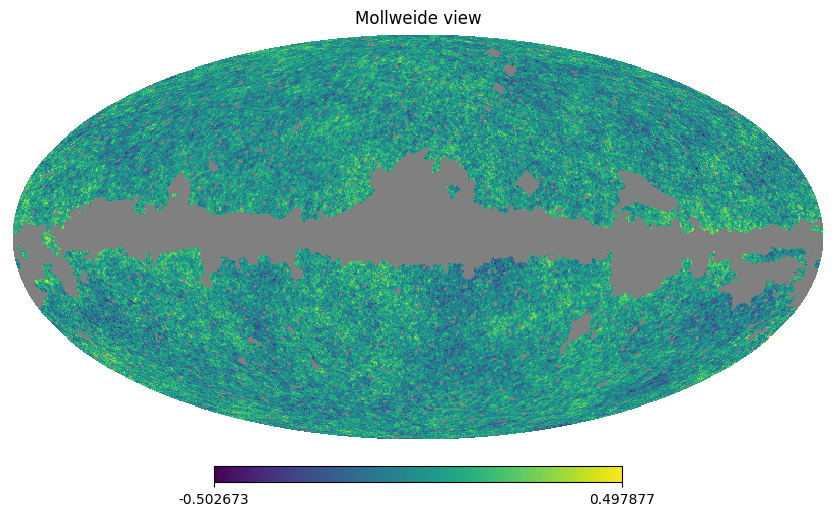

In [22]:
hp.mollview(wmap_map_I_masked.filled())

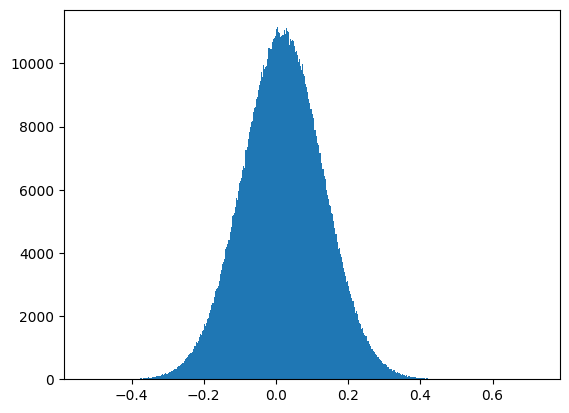

In [23]:
plt.hist(wmap_map_I_masked.compressed(), bins=1000);

In [24]:
LMAX = 1024
cl = hp.anafast(wmap_map_I_masked.filled(), lmax=LMAX)
ell = np.arange(len(cl))

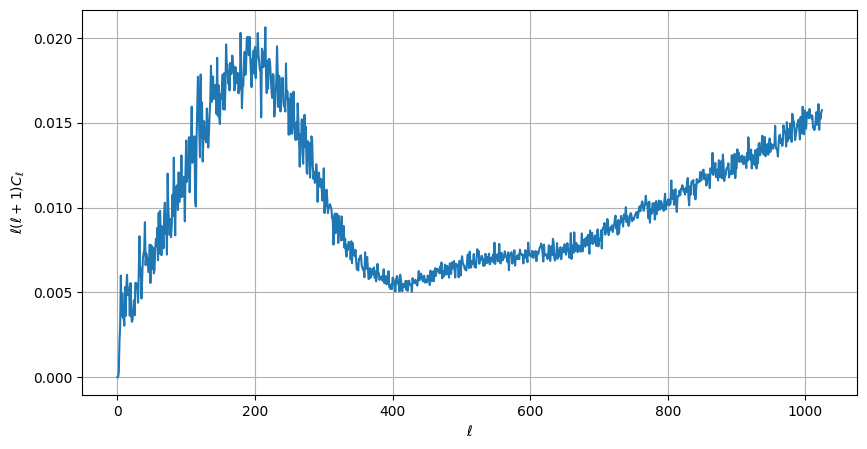

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

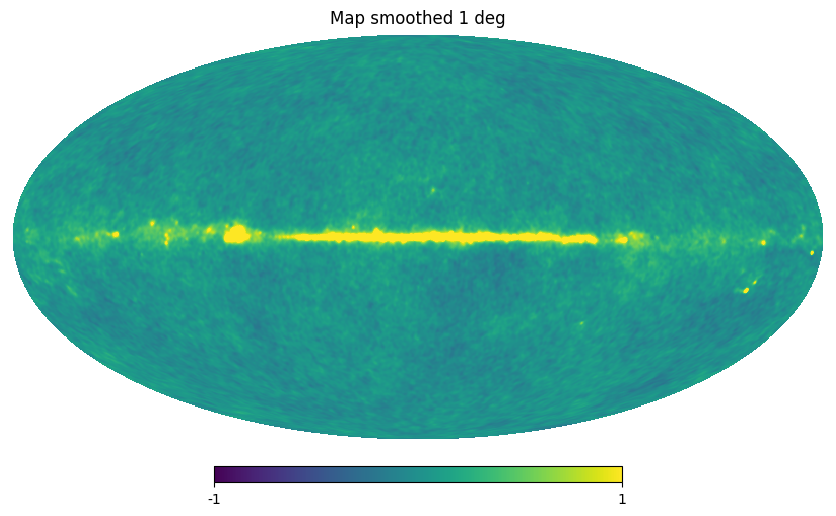

In [26]:
wmap_map_I_smoothed = hp.smoothing(wmap_map_I, fwhm=np.radians(1.))
hp.mollview(wmap_map_I_smoothed, min=-1, max=1, title="Map smoothed 1 deg")

In [27]:
#anafast
# 1. Apply the mask to the smoothed map
# We reuse the 'mask' variable defined earlier in your script
wmap_map_smoothed_masked = hp.ma(wmap_map_I_smoothed)
wmap_map_smoothed_masked.mask = np.logical_not(mask)

In [28]:
# 2. Calculate Cl using anafast
# We use the filled() method to handle masked pixels, just like before
cl_smoothed = hp.anafast(wmap_map_smoothed_masked.filled(), lmax=LMAX)
ell = np.arange(len(cl_smoothed))

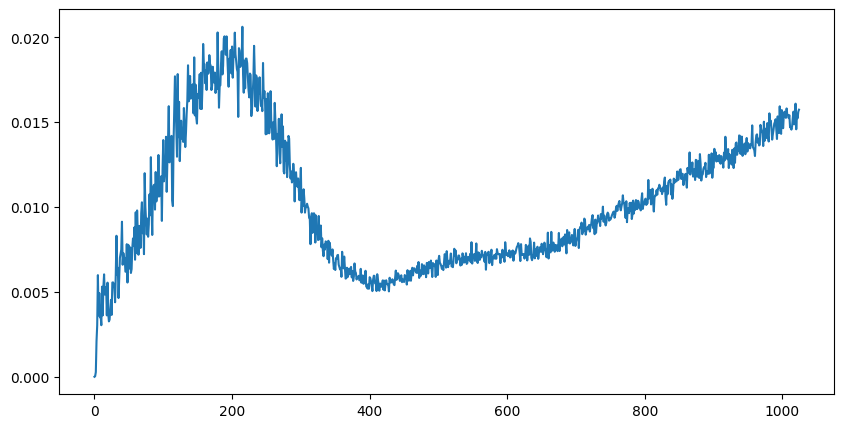

In [29]:
# 3. Plot the Power Spectrum
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl, label='Smoothed (1 deg)')

Text(0.5, 1.0, 'Power Spectrum of Smoothed Map')

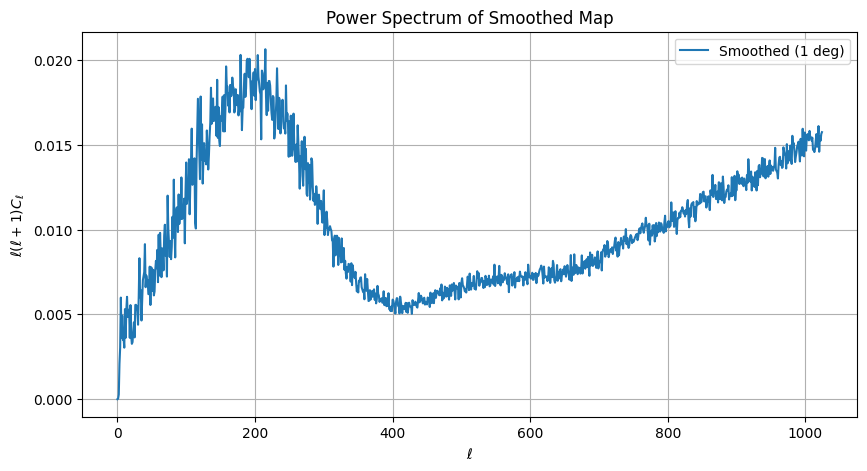

In [30]:
plt.figure(figsize=(10, 5))

# --- This is the missing line that creates the data for the legend ---
plt.plot(ell, ell * (ell + 1) * cl, label='Smoothed (1 deg)')
# -------------------------------------------------------------------

# Optional: Uncomment the line below to compare with the original map
# plt.plot(ell, ell * (ell + 1) * cl, alpha=0.5, label='Original')

plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.legend()  # Now this will find the 'Smoothed' label
plt.grid()
plt.title("Power Spectrum of Smoothed Map")

In [31]:
fits_file_path = "/Users/aydenyun/Documents/Cosmic Technology/Cosmic Technology/LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R4.00_full.fits"

In [32]:
I, Q, U = hp.read_map(fits_file_path, field=(0,1,2))

In [33]:
NSIDE = hp.get_nside(I)

In [34]:
print("Loaded map. NSIDE =", NSIDE)

Loaded map. NSIDE = 1024


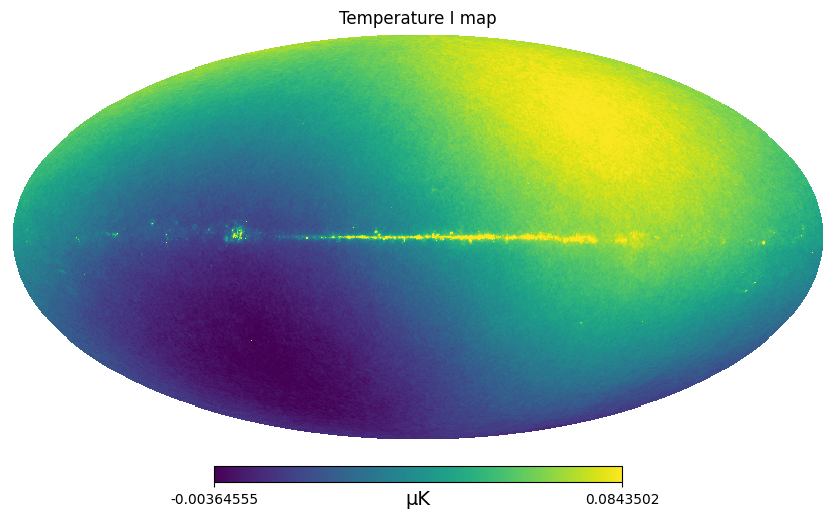

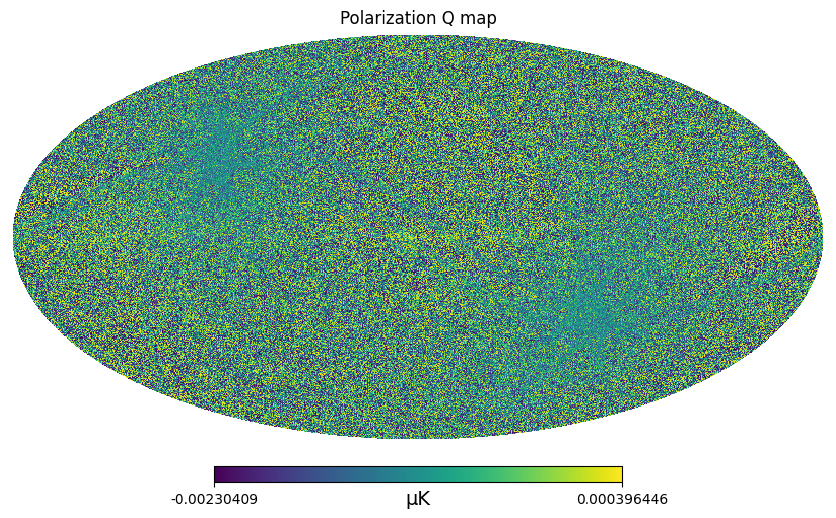

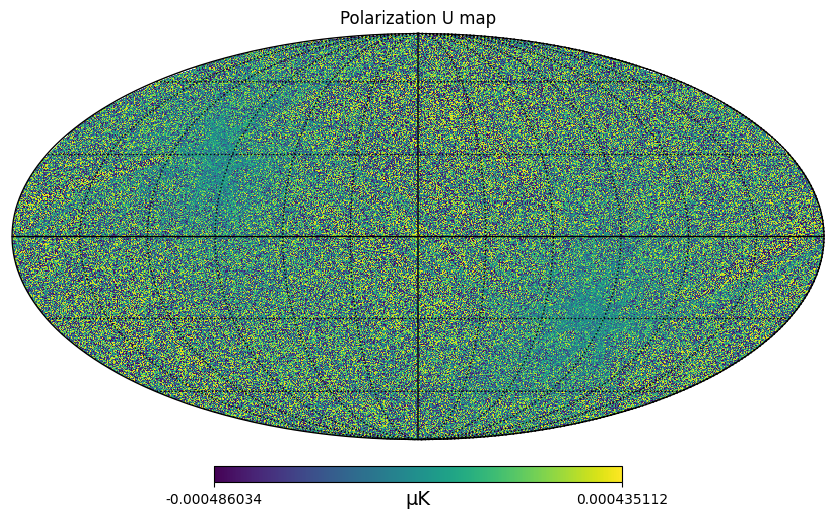

In [35]:
# mollview parameter to change the color scale for the map

hp.mollview(I, title="Temperature I map",unit ='μK', norm = 'hist')
hp.mollview(Q, title="Polarization Q map",unit ='μK', norm = 'hist')
hp.mollview(U, title="Polarization U map",unit ='μK', norm = 'hist')
hp.graticule()

In [36]:
mask = np.ones_like(I).astype(bool)  # no mask

In [37]:
#Apply to polarization:

Qm = hp.ma(Q)
Um = hp.ma(U)
Qm.mask = ~mask
Um.mask = ~mask

In [38]:
LMAX = 3*NSIDE - 1

almE, almB = hp.map2alm_spin([Qm.filled(), Um.filled()], spin=2, lmax=LMAX)

In [39]:
cl_EE = hp.alm2cl(almE, almE)
cl_BB = hp.alm2cl(almB, almB)
cl_EB = hp.alm2cl(almE, almB)

ell = np.arange(len(cl_EE))

Text(0.5, 1.0, 'Polarization Spectra from 70 GHz map')

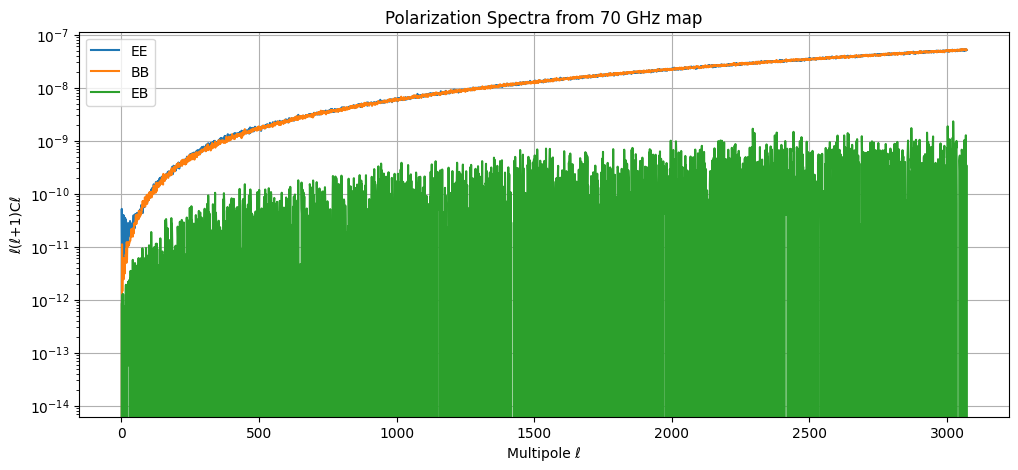

In [40]:
plt.figure(figsize=(12,5))
plt.plot(ell, ell*(ell+1)*cl_EE, label="EE")
plt.plot(ell, ell*(ell+1)*cl_BB, label="BB")
plt.plot(ell, ell*(ell+1)*cl_EB, label="EB")
plt.xlabel("Multipole ℓ")
plt.ylabel("ℓ(ℓ+1)Cℓ")
plt.yscale("log")
plt.legend()
plt.grid()
plt.title("Polarization Spectra from 70 GHz map")

EE scaling factor = 2.14e+06


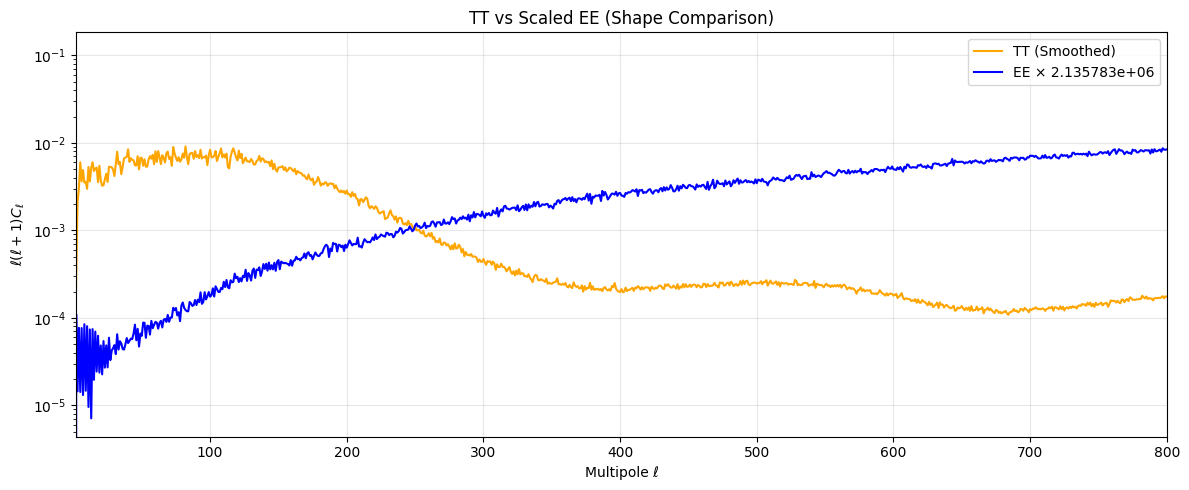

In [41]:
# --- Define ell arrays ---
ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))
# ell_BB = np.arange(len(cl_BB))
# ell_EB = np.arange(len(cl_EB))

# --- Compute Dl ---
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE
# Dl_BB = ell_BB * (ell_BB + 1) * cl_BB
# Dl_EB = ell_EB * (ell_EB + 1) * cl_EB

# --- Choose multipole range for scaling ---
lmin, lmax = 100, 400

# --- Protect against zeros / negatives in EE ---
valid = (
    (ell_EE >= lmin) &
    (ell_EE < lmax) &
    (Dl_EE > 0)
)

# --- Compute scaling factor ---
scale = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])

print(f"EE scaling factor = {scale:.2e}")

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange")
plt.plot(ell_EE, Dl_EE * scale, label=f"EE × {scale:2e}", color="blue")
# plt.plot(ell_EB, Dl_EB * scale, label=f"EE × {scale:.2e}", color="red")
# plt.plot(ell_BB, Dl_BB * scale, label=f"EE × {scale:.2e}", color="purple")
# Notation	Value
# 1e1	10
# 1e2	100
# 1e3	1,000
# 1e4	10,000
# 1e-1	0.1
# 1e-2	0.01

plt.xlim(2, 800)
plt.yscale("log")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell$")
plt.title("TT vs Scaled EE (Shape Comparison)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
# # --- Define ell arrays ---
# ell_TT = np.arange(len(cl_smoothed))
# ell_EE = np.arange(len(cl_EE))
# # ell_BB = np.arange(len(cl_BB))
# # ell_EB = np.arange(len(cl_EB))
#
# # --- Compute Dl ---
# Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed
# Dl_EE = ell_EE * (ell_EE + 1) * cl_EE
# # Dl_BB = ell_BB * (ell_BB + 1) * cl_BB
# # Dl_EB = ell_EB * (ell_EB + 1) * cl_EB
#
# # --- Choose multipole range for scaling ---
# lmin, lmax = 100, 400
#
# # --- Protect against zeros / negatives in EE ---
# valid = (
#     (ell_EE >= lmin) &
#     (ell_EE < lmax) &
#     (Dl_EE > 0)
# )
#
# # --- Compute scaling factor ---
# scale = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])
#
# print(f"EE scaling factor = {scale:.2e}")
#
# # --- Plot ---
# plt.figure(figsize=(12, 5))
# plt.plot(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange")
# plt.plot(ell_EE, Dl_EE * scale, label=f"EE × {scale:2e}", color="blue")
# # plt.plot(ell_EB, Dl_EB * scale, label=f"EE × {scale:.2e}", color="red")
# # plt.plot(ell_BB, Dl_BB * scale, label=f"EE × {scale:.2e}", color="purple")
# # Notation	Value
# # 1e1	10
# # 1e2	100
# # 1e3	1,000
# # 1e4	10,000
# # 1e-1	0.1
# # 1e-2	0.01
#
# plt.xlim(2, 800)
# plt.yscale("log")
#
# plt.xlabel("Multipole ℓ")
# plt.ylabel(r"$\ell(\ell+1)C_\ell$")
# plt.title("Zoom In")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.xlim(2, 80)          # zoom in ℓ
# plt.ylim(1e-5, 3e-4)     # zoom in Dl
# plt.yscale("log")
#
# plt.tight_layout()
# plt.show()


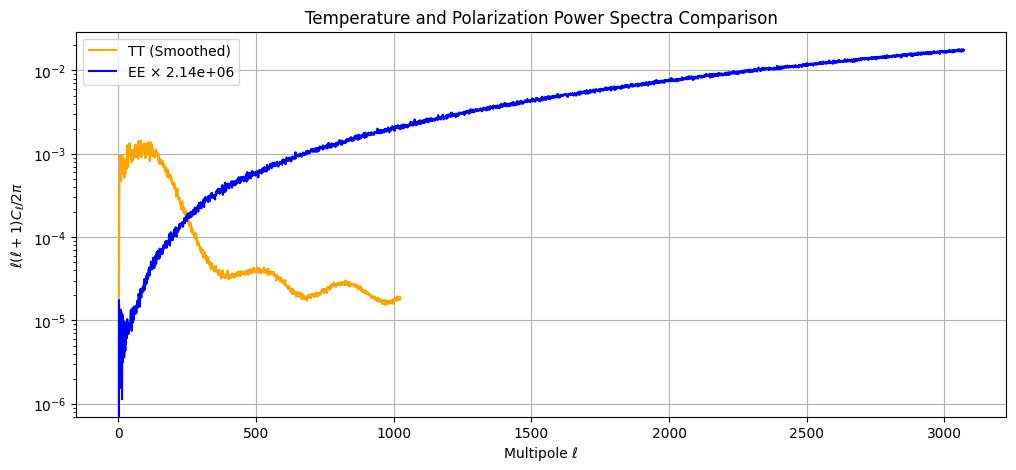

In [43]:
plt.figure(figsize=(12,5))

ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))

Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2 * np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2 * np.pi)

# Choose scaling range carefully
lmin, lmax = 100, 400
scale = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])

plt.plot(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange")
plt.plot(ell_EE, Dl_EE * scale, label=f"EE × {scale:.2e}", color="blue")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.yscale("log")
plt.legend()
plt.grid()
plt.title("Temperature and Polarization Power Spectra Comparison")
plt.show()


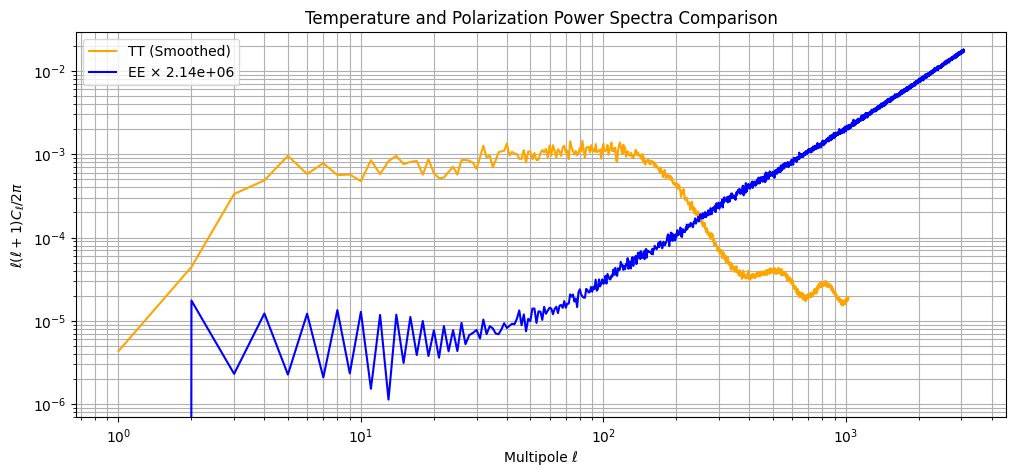

In [44]:
plt.figure(figsize=(12,5))

# start from ℓ=1 to avoid log(0) issues
ell_TT = np.arange(1, len(cl_smoothed))
ell_EE = np.arange(1, len(cl_EE))

Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed[1:] / (2 * np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE[1:] / (2 * np.pi)

lmin, lmax = 100, 400
scale = np.median(
    Dl_TT[lmin-1:lmax-1] / Dl_EE[lmin-1:lmax-1]
)

plt.loglog(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange")
plt.loglog(ell_EE, Dl_EE * scale, label=f"EE × {scale:.2e}", color="blue")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.legend()
plt.grid(True, which="both")
plt.title("Temperature and Polarization Power Spectra Comparison")
plt.show()

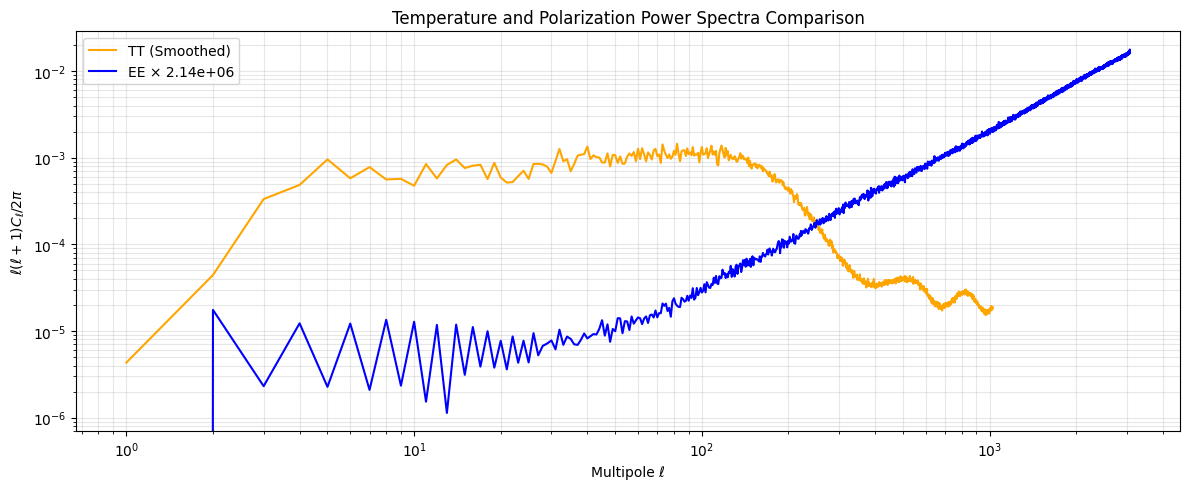

In [65]:
plt.figure(figsize=(12,5))

ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))

Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2 * np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2 * np.pi)

# Choose scaling range carefully
lmin, lmax = 100, 400
scale = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])

# Masks to remove ℓ = 0 only (required for log x-axis)
mask_TT = ell_TT > 0
mask_EE = ell_EE > 0

plt.plot(ell_TT[mask_TT], Dl_TT[mask_TT], label="TT (Smoothed)", color="orange")
plt.plot(ell_EE[mask_EE], Dl_EE[mask_EE] * scale, label=f"EE × {scale:.2e}", color="blue")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Temperature and Polarization Power Spectra Comparison")
plt.tight_layout()
plt.show()

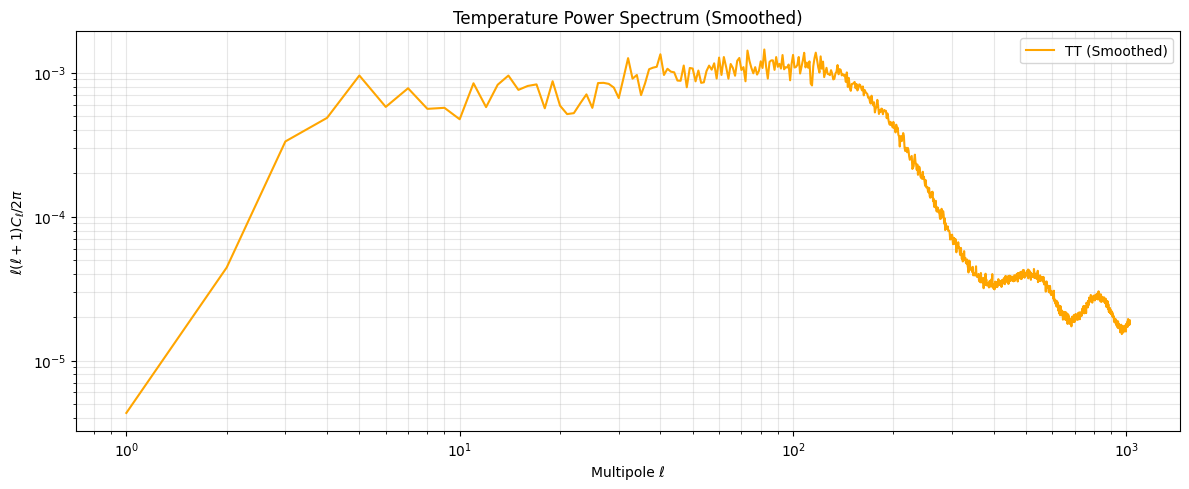

In [66]:
plt.figure(figsize=(12,5))

ell_TT = np.arange(len(cl_smoothed))

Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2 * np.pi)

# Remove ℓ = 0 (required for log x-axis)
mask_TT = ell_TT > 0

plt.plot(ell_TT[mask_TT], Dl_TT[mask_TT],
         label="TT (Smoothed)", color="orange")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Temperature Power Spectrum (Smoothed)")
plt.tight_layout()
plt.show()

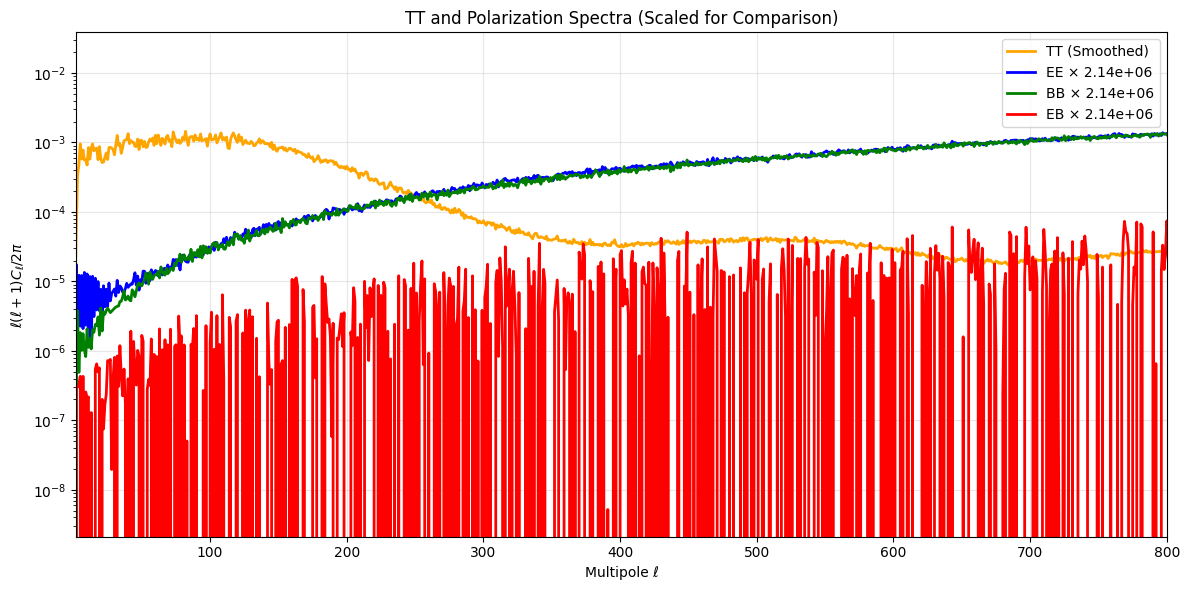

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define separate ell arrays ---
ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))
ell_BB = np.arange(len(cl_BB))
ell_EB = np.arange(len(cl_EB))

# --- Compute Dl ---
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2*np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2*np.pi)
Dl_BB = ell_BB * (ell_BB + 1) * cl_BB / (2*np.pi)
Dl_EB = ell_EB * (ell_EB + 1) * cl_EB / (2*np.pi)

# --- Scale factor to make EE comparable to TT ---
lmin, lmax = 100, 400  # choose multipole range for scaling
valid = (ell_EE >= lmin) & (ell_EE < lmax) & (Dl_EE > 0)
scale_EE = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])

# Optional: scale BB/EB by same factor
scale_BB = scale_EE
scale_EB = scale_EE

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange", linewidth=2)
plt.plot(ell_EE, Dl_EE * scale_EE, label=f"EE × {scale_EE:.2e}", color="blue", linewidth=2)
plt.plot(ell_BB, Dl_BB * scale_BB, label=f"BB × {scale_BB:.2e}", color="green", linewidth=2)
plt.plot(ell_EB, Dl_EB * scale_EB, label=f"EB × {scale_EB:.2e}", color="red", linewidth=2)

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.yscale("log")
plt.xlim(2, 800)
plt.title("TT and Polarization Spectra (Scaled for Comparison)")
plt.legend()
plt.grid(alpha=0.3)
# plt.xlim(2, 80)          # zoom in ℓ
# plt.ylim(1e-5, 3e-4)     # zoom in Dl
plt.tight_layout()
plt.show()


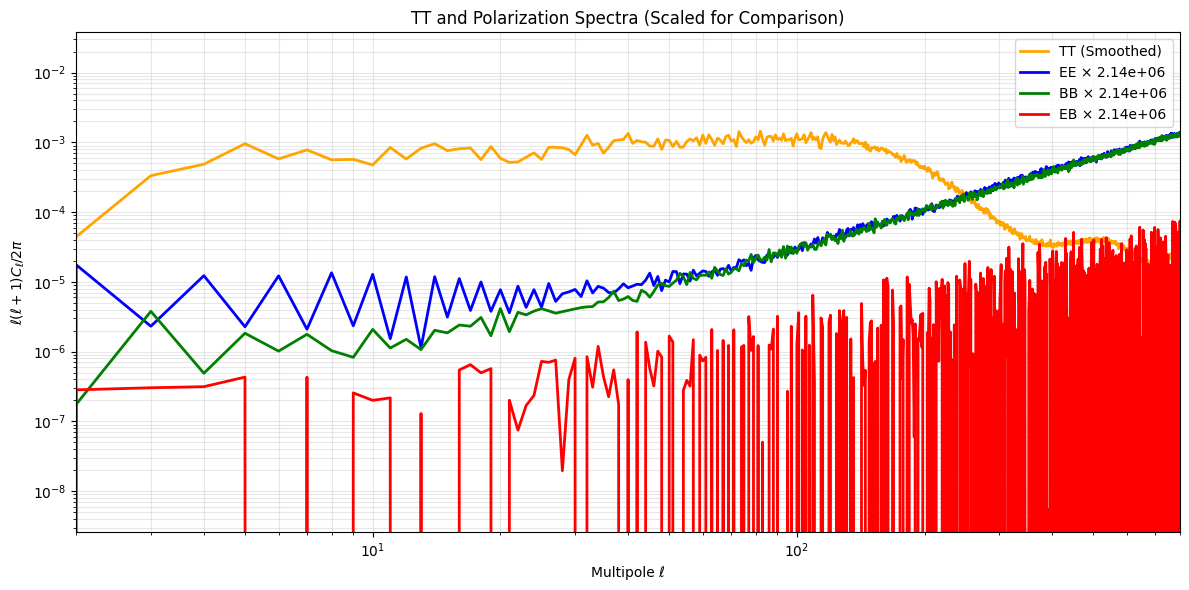

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define separate ell arrays ---
ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))
ell_BB = np.arange(len(cl_BB))
ell_EB = np.arange(len(cl_EB))

# --- Compute Dl ---
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2*np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2*np.pi)
Dl_BB = ell_BB * (ell_BB + 1) * cl_BB / (2*np.pi)
Dl_EB = ell_EB * (ell_EB + 1) * cl_EB / (2*np.pi)

# --- Scale factor to make EE comparable to TT ---
lmin, lmax = 100, 400  # choose multipole range for scaling
scale_EE = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])
scale_BB = scale_EE
scale_EB = scale_EE

# --- Masks to remove ℓ = 0 for log x-axis ---
mask_TT = ell_TT > 0
mask_EE = ell_EE > 0
mask_BB = ell_BB > 0
mask_EB = ell_EB > 0

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(ell_TT[mask_TT], Dl_TT[mask_TT],
         label="TT (Smoothed)", color="orange", linewidth=2)
plt.plot(ell_EE[mask_EE], Dl_EE[mask_EE] * scale_EE,
         label=f"EE × {scale_EE:.2e}", color="blue", linewidth=2)
plt.plot(ell_BB[mask_BB], Dl_BB[mask_BB] * scale_BB,
         label=f"BB × {scale_BB:.2e}", color="green", linewidth=2)
plt.plot(ell_EB[mask_EB], Dl_EB[mask_EB] * scale_EB,
         label=f"EB × {scale_EB:.2e}", color="red", linewidth=2)

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.xscale("log")
plt.yscale("log")
plt.xlim(2, 800)
plt.title("TT and Polarization Spectra (Scaled for Comparison)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

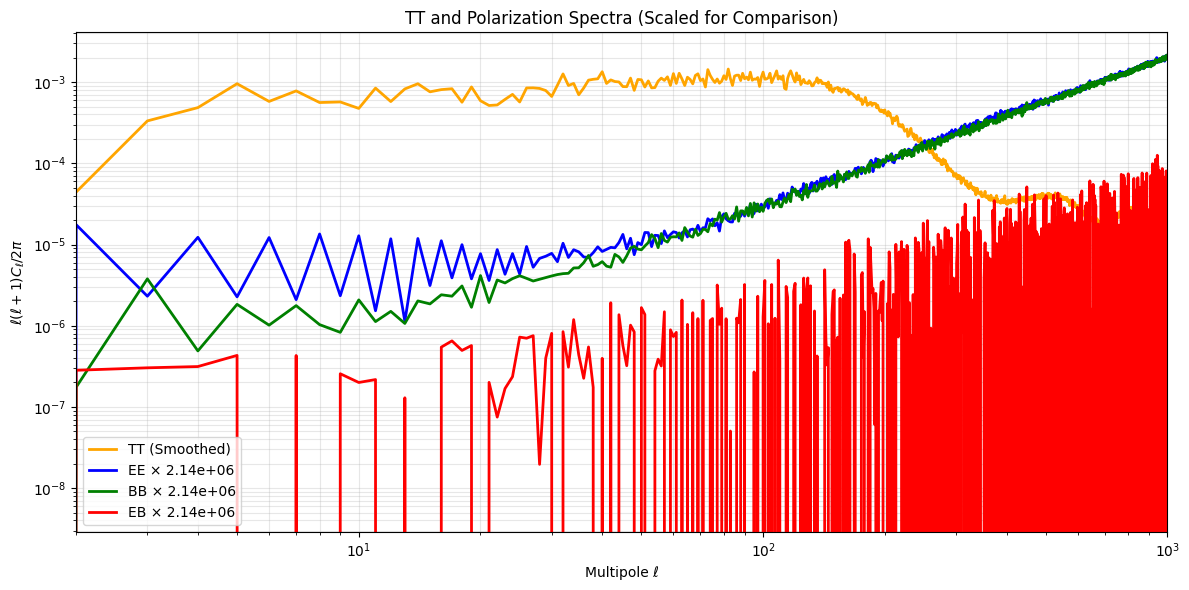

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define separate ell arrays ---
ell_TT = np.arange(len(cl_smoothed))
ell_EE = np.arange(len(cl_EE))
ell_BB = np.arange(len(cl_BB))
ell_EB = np.arange(len(cl_EB))

# --- Compute Dl ---
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2*np.pi)
Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2*np.pi)
Dl_BB = ell_BB * (ell_BB + 1) * cl_BB / (2*np.pi)
Dl_EB = ell_EB * (ell_EB + 1) * cl_EB / (2*np.pi)

# --- Scale factor to make EE comparable to TT (still use 100–400) ---
lmin, lmax = 100, 400
scale_EE = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])
scale_BB = scale_EE
scale_EB = scale_EE

# --- Masks: remove ℓ = 0 and restrict to ℓ ≤ 1000 for plotting ---
lmax_plot = 1000
mask_TT = (ell_TT > 0) & (ell_TT <= lmax_plot)
mask_EE = (ell_EE > 0) & (ell_EE <= lmax_plot)
mask_BB = (ell_BB > 0) & (ell_BB <= lmax_plot)
mask_EB = (ell_EB > 0) & (ell_EB <= lmax_plot)

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(ell_TT[mask_TT], Dl_TT[mask_TT],
         label="TT (Smoothed)", color="orange", linewidth=2)
plt.plot(ell_EE[mask_EE], Dl_EE[mask_EE] * scale_EE,
         label=f"EE × {scale_EE:.2e}", color="blue", linewidth=2)
plt.plot(ell_BB[mask_BB], Dl_BB[mask_BB] * scale_BB,
         label=f"BB × {scale_BB:.2e}", color="green", linewidth=2)
plt.plot(ell_EB[mask_EB], Dl_EB[mask_EB] * scale_EB,
         label=f"EB × {scale_EB:.2e}", color="red", linewidth=2)

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.xscale("log")
plt.yscale("log")
plt.xlim(2, lmax_plot)
plt.title("TT and Polarization Spectra (Scaled for Comparison)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [46]:
# import matplotlib.pyplot as plt
# import numpy as np
#
# # --- ell arrays ---
# ell_TT = np.arange(len(cl_smoothed))
# ell_EE = np.arange(len(cl_EE))
# ell_BB = np.arange(len(cl_BB))
# ell_EB = np.arange(len(cl_EB))
#
# # --- Compute Dl (ℓ(ℓ+1)Cℓ/2π) ---
# Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2*np.pi)  # smoothed TT
# Dl_EE = ell_EE * (ell_EE + 1) * cl_EE / (2*np.pi)
# Dl_BB = ell_BB * (ell_BB + 1) * cl_BB / (2*np.pi)
# Dl_EB = ell_EB * (ell_EB + 1) * cl_EB / (2*np.pi)
#
# # --- Scale factors to make polarization visible alongside TT ---
# lmin, lmax = 100, 400
# valid_EE = (ell_EE >= lmin) & (ell_EE < lmax) & (Dl_EE > 0)
# scale_EE = np.median(Dl_TT[lmin:lmax] / Dl_EE[lmin:lmax])
#
# valid_BB = (ell_BB >= lmin) & (ell_BB < lmax) & (Dl_BB > 0)
# scale_BB = np.median(Dl_TT[lmin:lmax] / Dl_BB[lmin:lmax])
#
# valid_EB = (ell_EB >= lmin) & (ell_EB < lmax) & (Dl_EB > 0)
# scale_EB = np.median(Dl_TT[lmin:lmax] / Dl_EB[lmin:lmax])
#
# # --- Plot all together ---
# plt.figure(figsize=(12,6))
#
# plt.plot(ell_TT, Dl_TT, label="TT (Smoothed)", color="orange", linewidth=2)
# plt.plot(ell_EE, Dl_EE * scale_EE, label=f"EE × {scale_EE:.2e}", color="blue", linewidth=2)
# plt.plot(ell_BB, Dl_BB * scale_BB, label=f"BB × {scale_BB:.2e}", color="green", linewidth=2)
# plt.plot(ell_EB, Dl_EB * scale_EB, label=f"EB × {scale_EB:.2e}", color="red", linewidth=2)
#
# plt.xlabel("Multipole ℓ")
# plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# plt.yscale("log")
# plt.xlim(2, 800)
# plt.title("TT and Polarization Spectra with Smoothed Map")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.xlim(2, 80)          # zoom in ℓ
# plt.ylim(1e-5, 3e-4)     # zoom in Dl
# plt.tight_layout()
# plt.show()


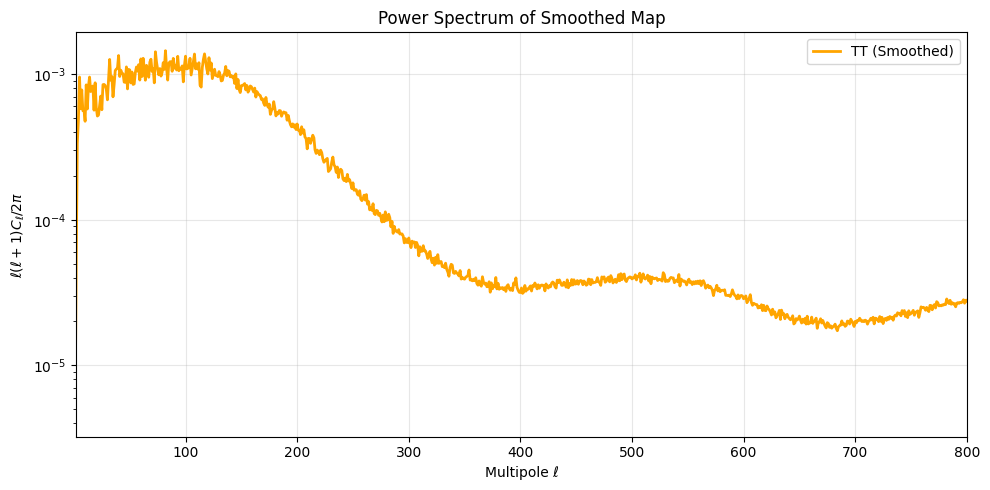

In [47]:
#extend to print out more

import matplotlib.pyplot as plt
import numpy as np

# ell array for TT
ell_TT = np.arange(len(cl_smoothed))

# Compute Dl (ℓ(ℓ+1)Cℓ / 2π)
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2 * np.pi)

# Plot
plt.figure(figsize=(10,5))
plt.plot(ell_TT, Dl_TT, color="orange", linewidth=2, label="TT (Smoothed)")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.title("Power Spectrum of Smoothed Map")
plt.yscale("log")
plt.xlim(2, 800)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


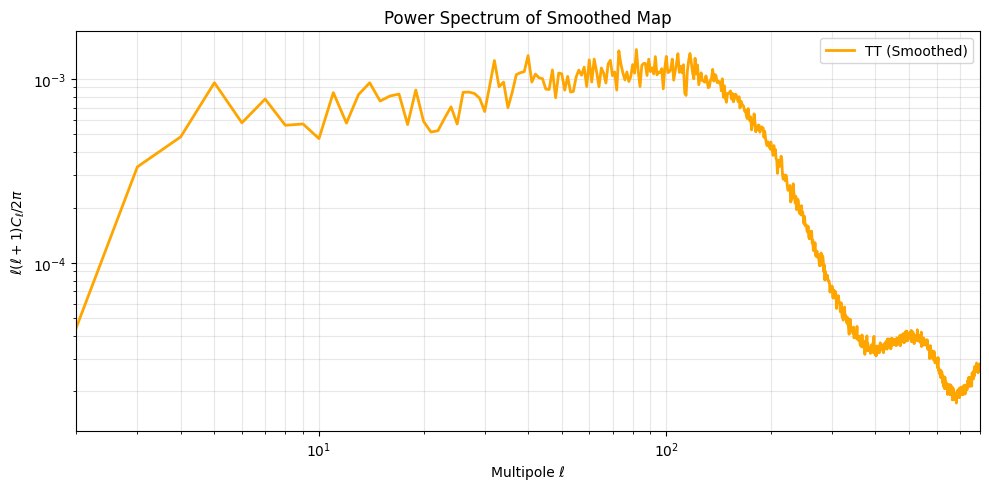

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# ell array for TT (start at ℓ=2 to avoid log(0))
ell_TT = np.arange(2, len(cl_smoothed))

# Compute Dl (ℓ(ℓ+1)Cℓ / 2π) using matching slice
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed[2:] / (2 * np.pi)

# Plot
plt.figure(figsize=(10,5))
plt.loglog(ell_TT, Dl_TT, color="orange", linewidth=2, label="TT (Smoothed)")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.title("Power Spectrum of Smoothed Map")
plt.xlim(2, 800)
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

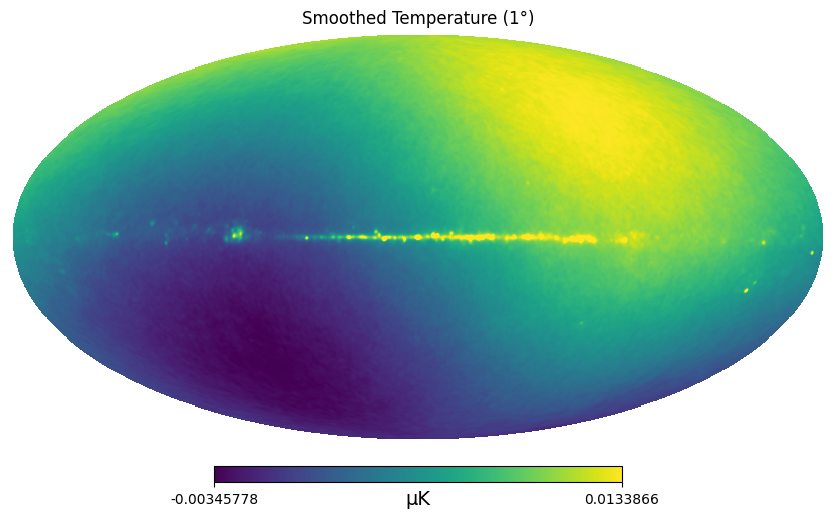

In [48]:
I_smooth = hp.smoothing(I, fwhm=np.radians(1.0))
hp.mollview(I_smooth, title="Smoothed Temperature (1°)", unit ='μK', norm = 'hist')

In [49]:
cl_all = hp.anafast([I, Q, U], lmax=LMAX)

In [50]:
cl_TT = cl_all[0]
cl_EE = cl_all[1]
cl_BB = cl_all[2]
cl_TE = cl_all[3]
cl_EB = cl_all[4] # This is the one you are specifically looking for

Text(0.5, 1.0, 'Spectra calculated via hp.anafast')

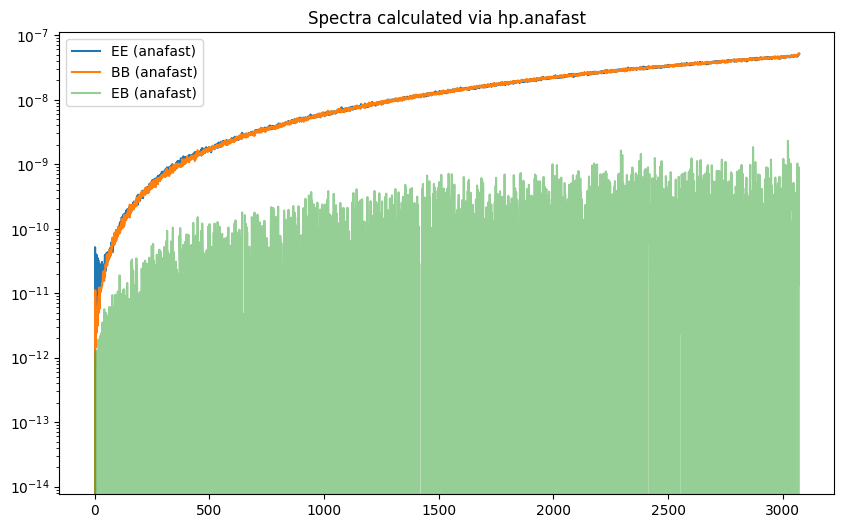

In [51]:
# Plotting check
plt.figure(figsize=(10,6))
plt.plot(ell, ell*(ell+1)*cl_EE, label="EE (anafast)")
plt.plot(ell, ell*(ell+1)*cl_BB, label="BB (anafast)")
plt.plot(ell, ell*(ell+1)*cl_EB, label="EB (anafast)", alpha=0.5)
plt.yscale('log')
plt.legend()
plt.title("Spectra calculated via hp.anafast")

In [52]:
maps = hp.read_map(fits_file_path, field=[0, 1, 2])

In [53]:
# 2. Downgrade for speed
NSIDE_LOW = 256
maps_low = hp.ud_grade(maps, nside_out=NSIDE_LOW)
I_low = maps_low[0]
Q_low = maps_low[1]
U_low = maps_low[2]

In [54]:
# --- KEY FIX: CONVERT TO MICROKELVIN (uK) ---
# This makes the numbers big enough to see on the plots
I_low = I_low * 1e6
Q_low = Q_low * 1e6
U_low = U_low * 1e6

In [55]:
# 3. Transform Q,U -> E,B
LMAX = 3 * NSIDE_LOW - 1
almE, almB = hp.map2alm_spin([Q_low, U_low], spin=2, lmax=LMAX)

In [56]:
# --- KEY FIX: USE alm2map (NOT SPIN) ---
# alm2map_spin returns Q and U.
# alm2map returns the scalar intensity of E and B.
E_map = hp.alm2map(almE, NSIDE_LOW)
B_map = hp.alm2map(almB, NSIDE_LOW)

In [57]:
# 4. Visualize E and B Maps
plt.figure(figsize=(15, 6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

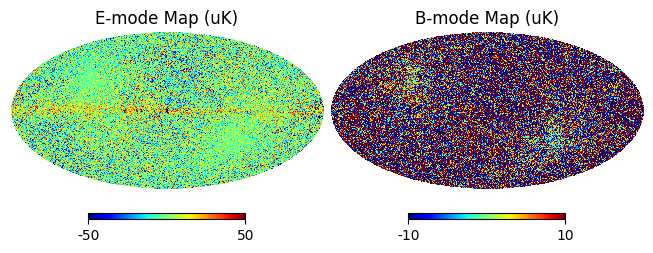

In [58]:
# E-mode (Should look bubbly/symmetric)
hp.mollview(E_map, sub=(1, 2, 1), title="E-mode Map (uK)",
            min=-50, max=50, cmap='jet')

# B-mode (Should be fainter/swirly)
hp.mollview(B_map, sub=(1, 2, 2), title="B-mode Map (uK)",
            min=-10, max=10, cmap='jet',norm = 'hist')
plt.show()

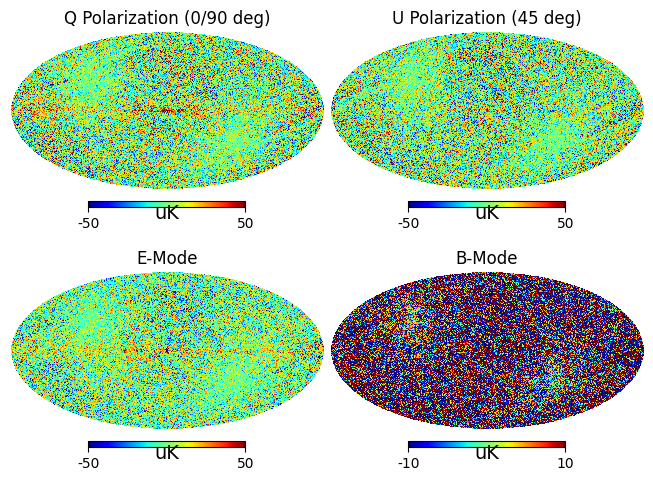

In [59]:
# Q Stokes
hp.mollview(Q_low, sub=(2,2,1), title="Q Polarization (0/90 deg)",
            min=-50, max=50, cmap='jet', unit='uK')

# U Stokes
hp.mollview(U_low, sub=(2,2,2), title="U Polarization (45 deg)",
            min=-50, max=50, cmap='jet', unit='uK')

# E-Mode
hp.mollview(E_map, sub=(2,2,3), title="E-Mode",
            min=-50, max=50, cmap='jet', unit='uK')

# B-Mode
# B modes are much fainter than E modes. We use a tighter scale (+/- 10)
hp.mollview(B_map, sub=(2,2,4), title="B-Mode",
            min=-10, max=10, cmap='jet', unit='uK')
plt.show()

<Figure size 1000x600 with 0 Axes>

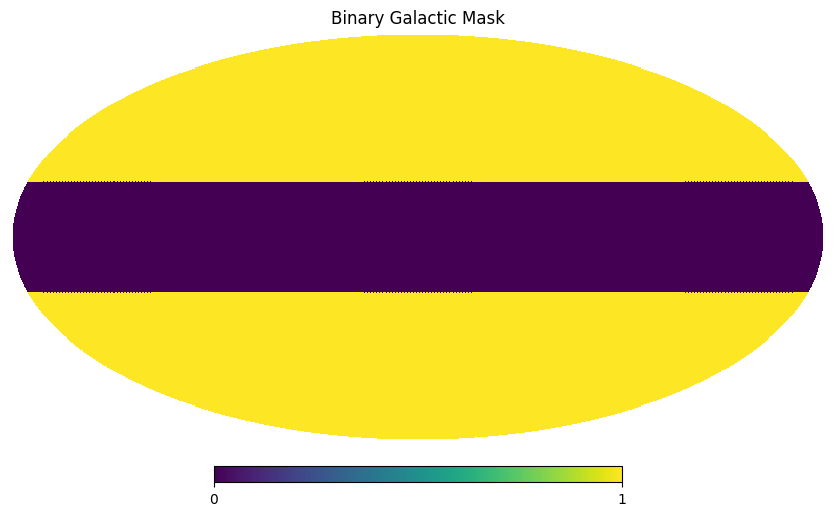

<Figure size 1000x600 with 0 Axes>

In [60]:
# ==========================================
# PART 2: THE MASKING PROBLEM
# ==========================================

# 1. Create Mask
theta, phi = hp.pix2ang(NSIDE_LOW, np.arange(hp.nside2npix(NSIDE_LOW)))
mask = np.ones(hp.nside2npix(NSIDE_LOW))
mask[np.abs(np.pi / 2 - theta) < np.radians(20)] = 0  # Cut 20 deg around equator

hp.mollview(mask, title="Binary Galactic Mask")

# 2. Apply Mask
# Note: I_low, Q_low, U_low are already in uK now!
Q_masked = Q_low * mask
U_masked = U_low * mask
I_masked = I_low * mask

# 3. Calculate Spectrum (Naive Anafast)
# We must use the uK maps so the spectrum isn't tiny
cl_masked = hp.anafast([I_masked, Q_masked, U_masked], lmax=LMAX)
cl_BB_masked = cl_masked[2]

# 4. Plot
ell = np.arange(len(cl_BB_masked))
plt.figure(figsize=(10, 6))

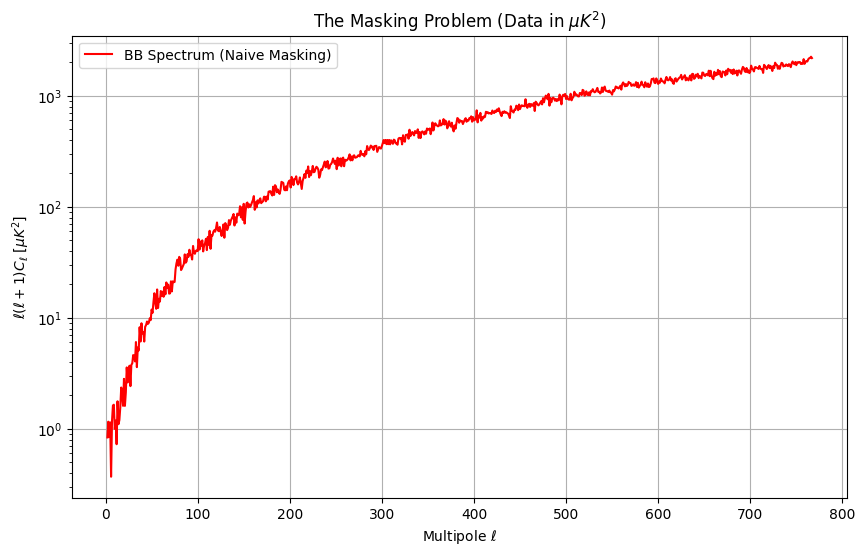

In [61]:
# ==========================================
# PART 2: THE MASKING PROBLEM
# ==========================================

# 1. Create Mask
theta, phi = hp.pix2ang(NSIDE_LOW, np.arange(hp.nside2npix(NSIDE_LOW)))
mask = np.ones(hp.nside2npix(NSIDE_LOW))
mask[np.abs(np.pi / 2 - theta) < np.radians(20)] = 0  # Cut 20 deg around equator

# 2. Apply Mask
# Note: I_low, Q_low, U_low are already in uK now!
Q_masked = Q_low * mask
U_masked = U_low * mask
I_masked = I_low * mask

# 3. Calculate Spectrum (Naive Anafast)
# We must use the uK maps so the spectrum isn't tiny
cl_masked = hp.anafast([I_masked, Q_masked, U_masked], lmax=LMAX)
cl_BB_masked = cl_masked[2]

# 4. Plot
ell = np.arange(len(cl_BB_masked))
plt.figure(figsize=(10, 6))

# We plot starting from l=2 because l=0,1 are usually garbage in polarization
plt.plot(ell[2:], (ell * (ell + 1) * cl_BB_masked)[2:], 'r-', label="BB Spectrum (Naive Masking)")

plt.yscale('log')
plt.title("The Masking Problem (Data in $\mu K^2$)")
plt.xlabel("Multipole $\ell$")
plt.ylabel("$\ell(\ell+1)C_\ell$ [$\mu K^2$]")
plt.legend()
plt.grid()
plt.show()

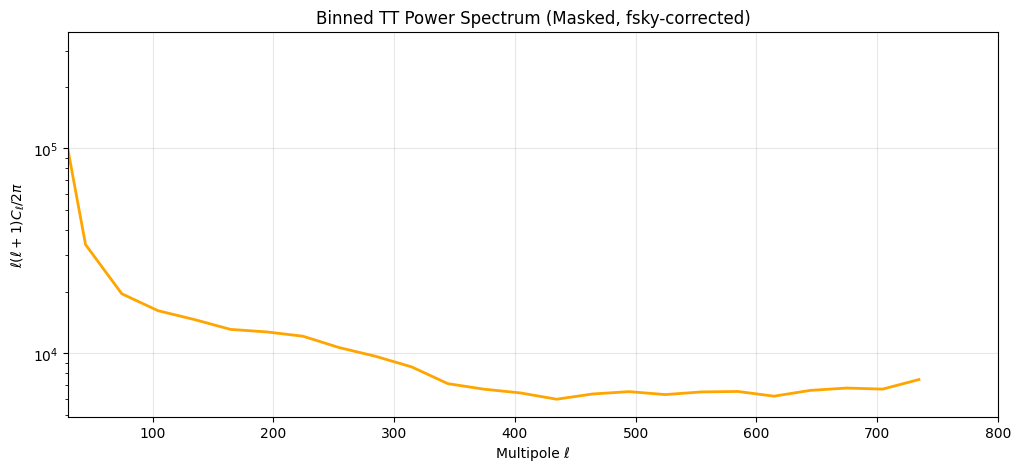

In [62]:
def bin_spectrum(ell, Dl, delta_ell=20):
    ell_bins = np.arange(0, ell.max(), delta_ell)
    Dl_binned = []
    ell_centers = []

    for i in range(len(ell_bins)-1):
        mask = (ell >= ell_bins[i]) & (ell < ell_bins[i+1])
        if np.sum(mask) > 0:
            Dl_binned.append(np.mean(Dl[mask]))
            ell_centers.append(np.mean(ell[mask]))

    return np.array(ell_centers), np.array(Dl_binned)



# --- Mask & fsky correction ---
fsky = np.mean(mask)
cl_TT = hp.anafast(I_masked, lmax=LMAX) / fsky

# --- Pixel window correction ---
pixwin = hp.pixwin(NSIDE_LOW, lmax=len(cl_TT)-1)
cl_TT /= pixwin**2

# --- Dl ---
ell = np.arange(len(cl_TT))
Dl_TT = ell * (ell + 1) * cl_TT / (2*np.pi)

# --- Bin ---
ell_b, Dl_b = bin_spectrum(ell, Dl_TT, delta_ell=30)

# --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(ell_b, Dl_b, color="orange", lw=2)
plt.yscale("log")
plt.xlim(30, 800)
plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.title("Binned TT Power Spectrum (Masked, fsky-corrected)")
plt.grid(alpha=0.3)
plt.show()


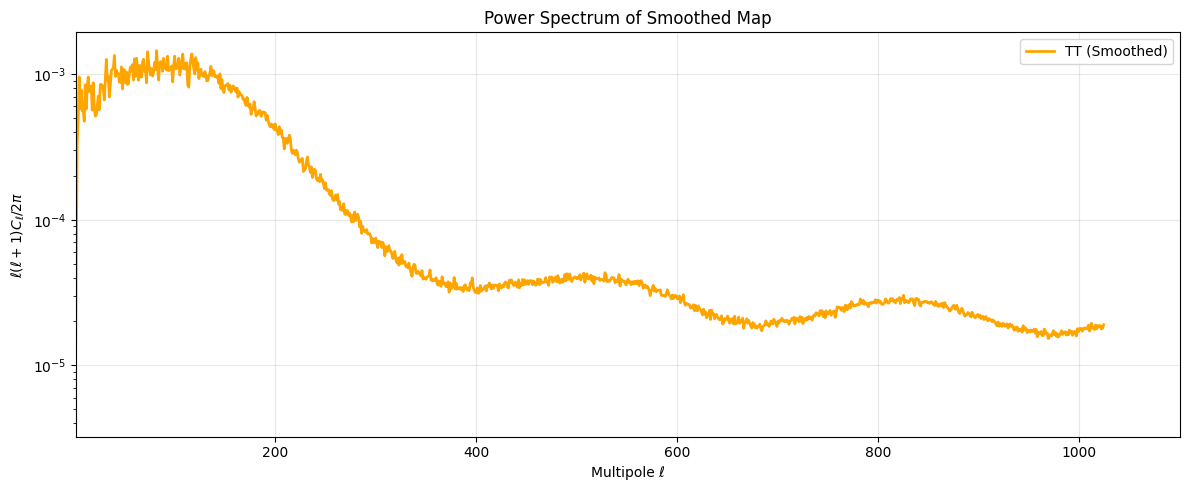

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# ell array for TT
ell_TT = np.arange(len(cl_smoothed))

# Compute Dl (ℓ(ℓ+1)Cℓ / 2π)
Dl_TT = ell_TT * (ell_TT + 1) * cl_smoothed / (2 * np.pi)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(ell_TT, Dl_TT, color="orange", linewidth=2, label="TT (Smoothed)")

plt.xlabel("Multipole ℓ")
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.title("Power Spectrum of Smoothed Map")
plt.yscale("log")

plt.xlim(2, 1100)   # <-- extended to 1000
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
